# Estudo lateral — Tempos dos Alarmes

## Princípio orientador

> **Este notebook estabelece uma base de investigação sem remover registros e sem converter
> anomalias em erros por suposição. Os resultados devem orientar a preparação da base auditada.**

Este é um estudo lateral, não uma etapa numerada da preparação dos dados. Seu objetivo é separar e
relacionar dois conceitos:

- **cadência de emissão:** tempo observado entre registros consecutivos do mesmo alarme;
- **janela da regra de negócio:** período no qual uma quantidade de ocorrências deve ser avaliada.

Uma cadência frequente não prova que registros próximos pertençam ao mesmo episódio. Da mesma forma,
o campo `TEMPO` de uma regra não deve ser adotado automaticamente como separação entre episódios.
Nenhum registro é removido ou reclassificado neste notebook.

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 150)

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
BASE = ROOT / "data" / "raw" / "Base"
TEL_GLOB = str(BASE / "datasets" / "telemetria" / "telemetry_*.parquet")
RULES_PATH = BASE / "Alarmes - Regra de Negocio.xlsx"

con = duckdb.connect()
con.execute("SET threads=4")
con.execute(f"CREATE OR REPLACE VIEW tel AS SELECT * FROM read_parquet('{TEL_GLOB}', union_by_name=true)")

def query(sql):
    return con.sql(sql).df()

rules = pd.read_excel(RULES_PATH, sheet_name="CMA")
print(f"Raiz do projeto: {ROOT}")
print(f"Regras CMA: {len(rules):,}")

Raiz do projeto: /home/f_szekut/projects/vale_correct
Regras CMA: 151


## 1. O que as regras temporais exigem

As regras combinam `QTD` e `TEMPO`. Por exemplo, `QTD = 5` e `TEMPO = 360` descreve uma decisão
dependente de cinco ocorrências dentro de uma janela de 360 minutos, sujeita também à interpretação
de `SITUACAO` e `NIVEL`.

### Regra de negócio associada ao gráfico

- `QTD = 1` e `TEMPO = 0`: candidata a avaliação por ocorrência isolada;
- `QTD > 1` ou `TEMPO > 0`: exige uma definição executável de contagem, janela e consecutividade;
- regras com o mesmo evento podem possuir condições diferentes e devem permanecer distintas.

,QTD,TEMPO,regras
0,1,0,89
5,5,720,24
1,2,360,15
4,5,360,7
2,3,360,6
3,3,720,4
6,10,360,3
7,10,720,3


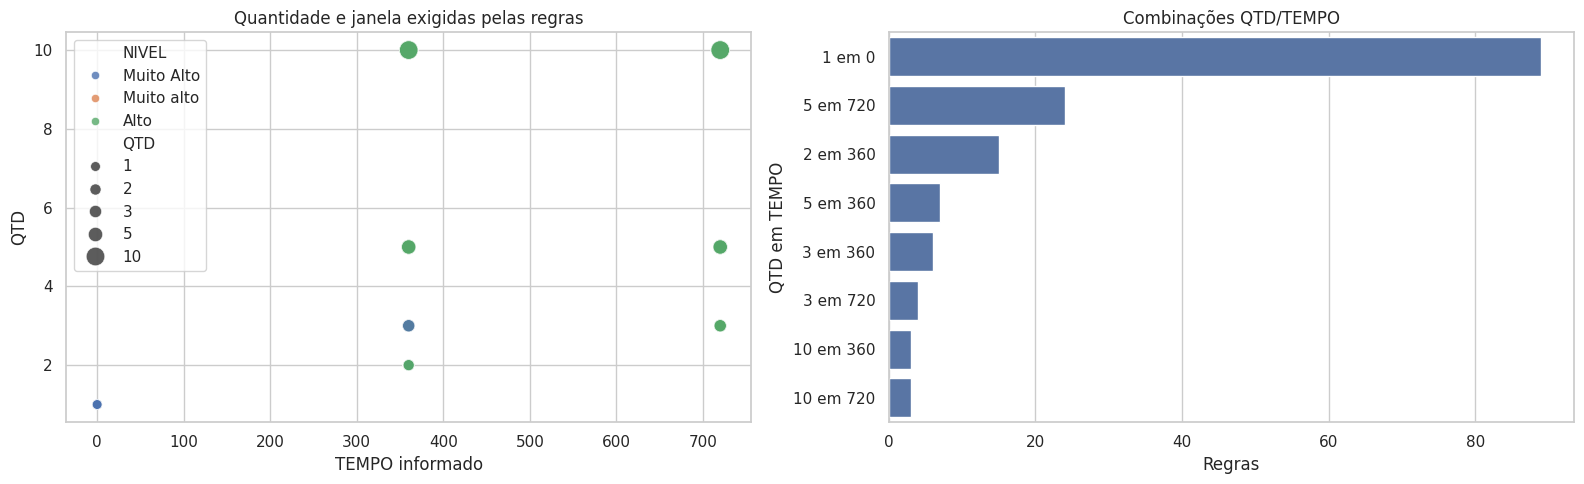

In [2]:
rule_pairs = (
    rules.groupby(["QTD", "TEMPO"], dropna=False)
    .size().reset_index(name="regras")
    .sort_values("regras", ascending=False)
)
display(rule_pairs)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.scatterplot(
    data=rules, x="TEMPO", y="QTD", hue="NIVEL", size="QTD",
    sizes=(50, 180), alpha=.8, ax=axes[0]
)
axes[0].set(title="Quantidade e janela exigidas pelas regras", xlabel="TEMPO informado", ylabel="QTD")
sns.barplot(data=rule_pairs, x="regras", y=rule_pairs.apply(lambda x: f"{int(x.QTD)} em {int(x.TEMPO)}", axis=1), ax=axes[1])
axes[1].set(title="Combinações QTD/TEMPO", xlabel="Regras", ylabel="QTD em TEMPO")
plt.tight_layout()
plt.show()

## 2. Cadência global observada

Calculamos o intervalo entre registros consecutivos da mesma combinação `TAG + Id_Alarme`.
O agrupamento inclui todos os registros porque a finalidade é compreender o comportamento de
emissão, não apenas os eventos classificados como `Dont Go`.

### Regra de negócio associada ao gráfico

Não existe justificativa para assumir emissão a cada segundo. Uma janela temporal precisa tolerar
cadências distintas sem confundir repetição de transmissão com novas ocorrências operacionais.

,quantil,gap_ms
0,0.10,97.00
1,0.25,1367.00
2,0.50,6100.00
3,0.75,24766.00
4,0.90,78580.00
5,0.95,600646.00
6,0.99,4081752.61


,faixa,intervalos,percentual
0,0 ms,265828,0.715414
1,1–99 ms,3476539,9.356299
2,100–999 ms,4311890,11.604452
3,1–<5 s,8766201,23.592198
4,5–<10 s,6519547,17.545849
5,10–<60 s,9516685,25.611951
6,1–<5 min,1788130,4.812337
7,5–<60 min,2097005,5.643603
8,≥1 h,415379,1.117896


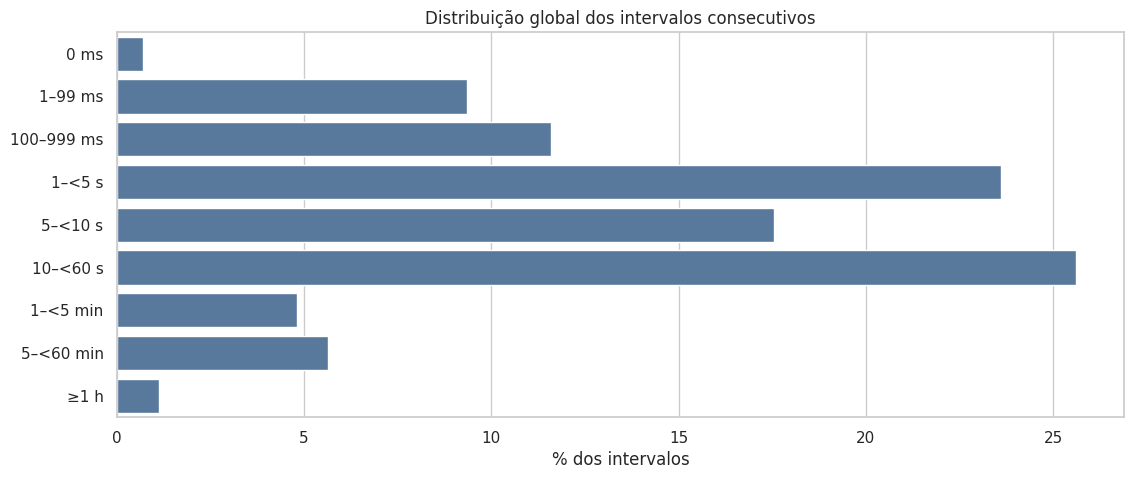

In [3]:
global_gaps = query(
    '''
    WITH gaps AS (
        SELECT date_diff(
                   'millisecond',
                   lag(Data_Evento) OVER (PARTITION BY TAG, Id_Alarme ORDER BY Data_Evento),
                   Data_Evento
               ) AS gap_ms
        FROM tel
    )
    SELECT gap_ms FROM gaps WHERE gap_ms IS NOT NULL AND gap_ms >= 0
    '''
)

quantiles = global_gaps["gap_ms"].quantile([.10, .25, .50, .75, .90, .95, .99]).rename("gap_ms").reset_index()
quantiles.columns = ["quantil", "gap_ms"]
display(quantiles)

bins = [-1, 0, 99, 999, 4_999, 9_999, 59_999, 299_999, 3_599_999, np.inf]
labels = ["0 ms", "1–99 ms", "100–999 ms", "1–<5 s", "5–<10 s", "10–<60 s", "1–<5 min", "5–<60 min", "≥1 h"]
global_gaps["faixa"] = pd.cut(global_gaps["gap_ms"], bins=bins, labels=labels)
gap_bands = global_gaps["faixa"].value_counts(sort=False).rename_axis("faixa").reset_index(name="intervalos")
gap_bands["percentual"] = 100 * gap_bands["intervalos"] / gap_bands["intervalos"].sum()
display(gap_bands)

fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=gap_bands, x="percentual", y="faixa", color="#4C78A8", ax=ax)
ax.set(title="Distribuição global dos intervalos consecutivos", xlabel="% dos intervalos", ylabel="")
plt.show()

## 3. Perfil temporal por alarme

O mapa preferencial deve ser definido por `Id_Alarme`, pois esse identificador pode generalizar para
novos equipamentos. Para reduzir conclusões baseadas em amostras pequenas, o gráfico mostra apenas
alarmes com pelo menos 100 intervalos observados.

### Regra de negócio associada ao gráfico

O tempo típico por alarme é evidência para interpretar contagens em uma janela. Ele ainda não define
sozinho o encerramento de um episódio. Alarmes com poucos dados devem usar uma referência mais geral,
nunca um parâmetro específico estimado sem suporte.

,Id_Alarme,Alarme,intervalos,tags,mediana_ms,p90_ms,p99_ms
554,1241579532,Engine \/ Retarder Torque Mode - Not Defined\/...,7701065,5,1567.0,11444.0,52966.00
277,1241579521,Engine \/ Retarder Torque Mode - Accelerator P...,6321683,5,1594.0,13857.0,68010.54
842,1074008255,Vehicle Speed Too Low (L-1850),6038222,5,5196.0,11373.0,49170.00
0,1074008254,Vehicle Speed Too High,3369388,5,9330.0,17667.0,84687.39
843,1241579528,Engine \/ Retarder Torque Mode - Torque Limiting,2273150,5,7567.0,40077.0,190140.00
854,1074008235,Bucket Angle At Or Above Level,1150070,5,31440.0,61197.0,375491.24
700,1074008262,Rollback Stick Limited By End Of Travel,840307,5,41880.0,84224.0,554368.96
855,1074008258,Left Steer Limited By End Of Travel,728760,5,36450.0,119950.3,849942.30
584,1074008247,Lift Arms Too High,723692,5,44767.0,83630.0,638641.23
305,1074008259,Lower Hoist Limited By End Of Travel,711447,5,39470.0,113210.0,1015762.98


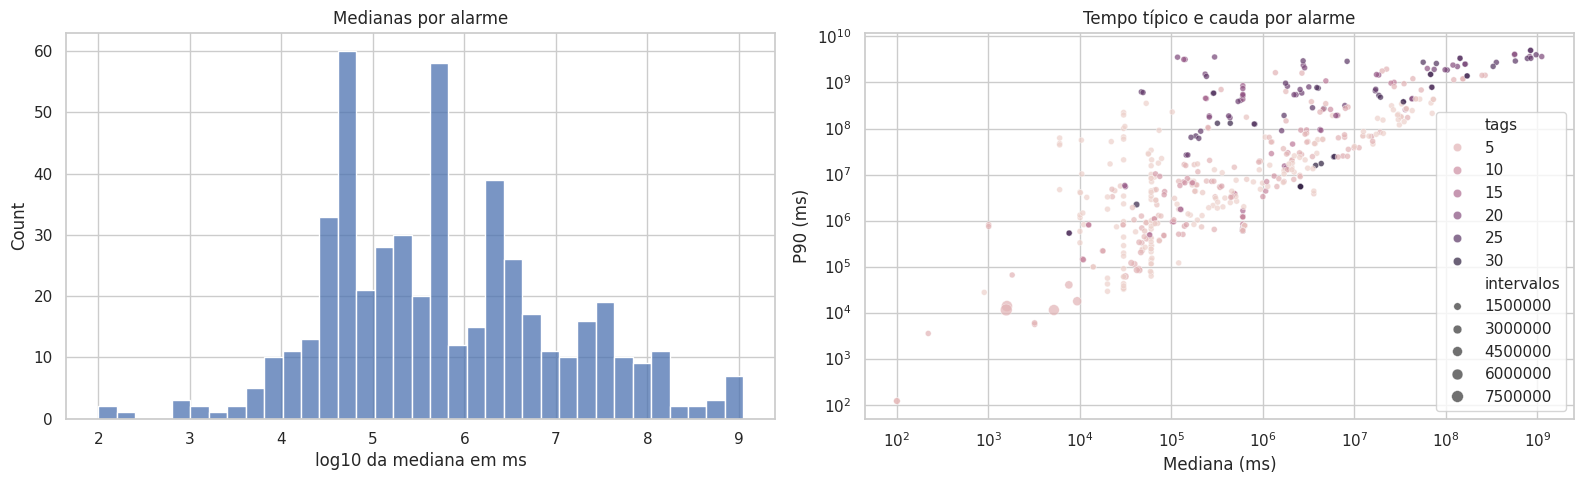

In [4]:
alarm_timing = query(
    '''
    WITH gaps AS (
        SELECT Id_Alarme, Alarme, TAG,
               date_diff('millisecond',
                   lag(Data_Evento) OVER (PARTITION BY TAG, Id_Alarme ORDER BY Data_Evento),
                   Data_Evento
               ) AS gap_ms
        FROM tel
    )
    SELECT Id_Alarme, any_value(Alarme) AS Alarme,
           count(*) AS intervalos, count(DISTINCT TAG) AS tags,
           median(gap_ms) AS mediana_ms,
           quantile_cont(gap_ms, .90) AS p90_ms,
           quantile_cont(gap_ms, .99) AS p99_ms
    FROM gaps
    WHERE gap_ms IS NOT NULL AND gap_ms >= 0
    GROUP BY Id_Alarme
    '''
)
eligible_alarm_timing = alarm_timing[alarm_timing["intervalos"] >= 100].copy()
display(alarm_timing.sort_values("intervalos", ascending=False).head(30))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(np.log10(eligible_alarm_timing["mediana_ms"].clip(lower=1)), bins=35, ax=axes[0])
axes[0].set(title="Medianas por alarme", xlabel="log10 da mediana em ms")
sns.scatterplot(data=eligible_alarm_timing, x="mediana_ms", y="p90_ms", size="intervalos", hue="tags", alpha=.7, ax=axes[1])
axes[1].set(xscale="log", yscale="log", title="Tempo típico e cauda por alarme", xlabel="Mediana (ms)", ylabel="P90 (ms)")
plt.tight_layout()
plt.show()

## 4. O mesmo alarme mantém a cadência entre equipamentos?

Para cada `Id_Alarme + TAG`, calculamos a mediana dos intervalos. Em seguida, medimos a razão entre
as medianas mais alta e mais baixa observadas entre TAGs do mesmo alarme. O gráfico considera apenas
combinações com pelo menos 100 intervalos e alarmes presentes em pelo menos três TAGs.

### Regra de negócio associada ao gráfico

- baixa variação entre TAGs favorece um parâmetro por `Id_Alarme`;
- alta variação exige investigação antes de criar parâmetro por `Id_Alarme + TAG`;
- parâmetros por TAG são último recurso, pois não generalizam para equipamentos novos.

,Id_Alarme,tags,mediana_min_ms,mediana_max_ms,mediana_das_tags_ms,razao_max_min
428,1241645025,5,3194.0,8877070.0,5698506.50,2779.295554
427,1241645024,5,3183.0,8266010.0,5705947.00,2596.924285
238,84609103,4,26520.0,49352106.0,5151416.75,1860.939140
237,84609102,4,28054.0,47060153.5,2936873.00,1677.484619
422,1241586688,5,31007.0,10472891.5,64949.50,337.758942
288,84612811,15,354673.0,92760281.5,30910630.00,261.537477
285,84612808,25,53010.0,13766603.0,4495196.00,259.698227
287,84612810,15,357244.0,92756305.0,30914717.00,259.644123
180,84607105,7,132511.5,30246050.0,1161167.00,228.252265
179,84607104,7,144041.5,31675797.0,1162084.00,219.907436


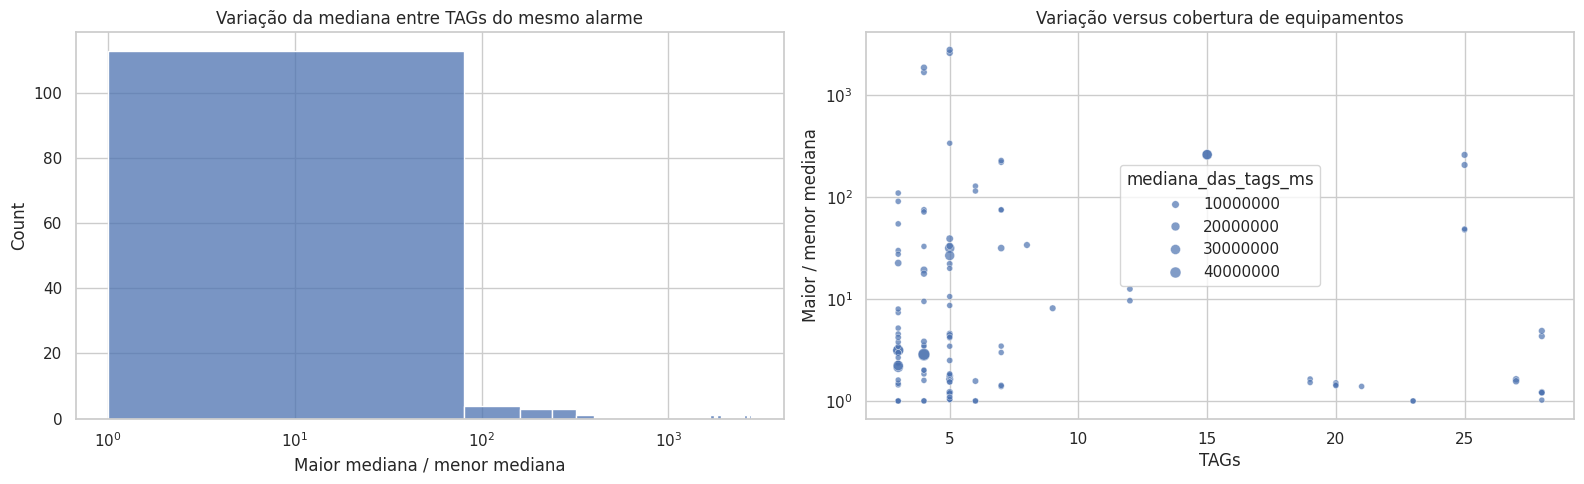

In [5]:
tag_alarm_timing = query(
    '''
    WITH gaps AS (
        SELECT TAG, Id_Alarme,
               date_diff('millisecond',
                   lag(Data_Evento) OVER (PARTITION BY TAG, Id_Alarme ORDER BY Data_Evento),
                   Data_Evento
               ) AS gap_ms
        FROM tel
    )
    SELECT TAG, Id_Alarme, count(*) AS intervalos, median(gap_ms) AS mediana_ms
    FROM gaps
    WHERE gap_ms IS NOT NULL AND gap_ms >= 0
    GROUP BY TAG, Id_Alarme
    '''
)
stable_samples = tag_alarm_timing[tag_alarm_timing["intervalos"] >= 100].copy()
between_tags = (
    stable_samples.groupby("Id_Alarme")
    .agg(tags=("TAG", "nunique"), mediana_min_ms=("mediana_ms", "min"),
         mediana_max_ms=("mediana_ms", "max"), mediana_das_tags_ms=("mediana_ms", "median"))
    .reset_index()
)
between_tags = between_tags[between_tags["tags"] >= 3].copy()
between_tags["razao_max_min"] = between_tags["mediana_max_ms"] / between_tags["mediana_min_ms"].clip(lower=1)
display(between_tags.sort_values("razao_max_min", ascending=False).head(40))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(data=between_tags, x="razao_max_min", bins=35, ax=axes[0])
axes[0].set(xscale="log", title="Variação da mediana entre TAGs do mesmo alarme", xlabel="Maior mediana / menor mediana")
sns.scatterplot(data=between_tags, x="tags", y="razao_max_min", size="mediana_das_tags_ms", alpha=.7, ax=axes[1])
axes[1].set(yscale="log", title="Variação versus cobertura de equipamentos", xlabel="TAGs", ylabel="Maior / menor mediana")
plt.tight_layout()
plt.show()

## 5. Relação entre catálogo e telemetria

As regras são descritas pelo nome `EVENTO`, enquanto a telemetria dispõe de `Id_Alarme` e `Alarme`.
Antes de confrontar cadências com `QTD/TEMPO`, medimos a cobertura do vínculo nominal exato.

### Regra de negócio associada ao gráfico

Uma regra somente pode ser executada automaticamente depois que seu evento estiver vinculado de
forma verificável ao identificador da telemetria. Ausência de correspondência nominal não significa
ausência do evento: pode indicar diferença de nomenclatura ou catálogo.

In [6]:
telemetry_names = query("SELECT DISTINCT Id_Alarme, trim(Alarme) AS EVENTO FROM tel")
rule_link = rules.merge(telemetry_names, how="left", on="EVENTO")
coverage = pd.DataFrame({
    "metrica": ["Regras", "Eventos distintos nas regras", "Eventos com correspondência nominal", "Regras vinculadas nominalmente"],
    "valor": [len(rules), rules["EVENTO"].nunique(), rule_link.loc[rule_link["Id_Alarme"].notna(), "EVENTO"].nunique(), rule_link["Id_Alarme"].notna().sum()]
})
display(coverage)

linked_rules = rule_link.merge(alarm_timing, how="left", on="Id_Alarme", suffixes=("_regra", "_telemetria"))
display(
    linked_rules[linked_rules["Id_Alarme"].notna()][
        ["EVENTO", "SITUACAO", "QTD", "TEMPO", "NIVEL", "Id_Alarme", "intervalos", "tags", "mediana_ms", "p90_ms", "p99_ms"]
    ].sort_values(["TEMPO", "QTD"], ascending=False)
)

,metrica,valor
0,Regras,151
1,Eventos distintos nas regras,136
2,Eventos com correspondência nominal,19
3,Regras vinculadas nominalmente,65


,EVENTO,SITUACAO,QTD,TEMPO,NIVEL,Id_Alarme,intervalos,tags,mediana_ms,p90_ms,p99_ms
49,Engine Oil Level - Active,Mediante cinco alarmes nivel 2 consecutivos.,5,720,Alto,8.460980e+07,44.0,10.0,8.649172e+06,6.146300e+09,1.023827e+10
73,Left Exhaust Temperature - Active,Mediante cinco alarmes nível 1 e 2 consecutivos.,5,720,Alto,8.460861e+07,470.0,24.0,2.413485e+05,1.358739e+09,4.785602e+09
74,Left Exhaust Temperature - Active,Mediante cinco alarmes nível 1 e 2 consecutivos.,5,720,Alto,8.460982e+07,114.0,12.0,2.508784e+07,9.677326e+08,5.267150e+09
75,Left Exhaust Temperature - Active,Mediante cinco alarmes nível 1 e 2 consecutivos.,5,720,Alto,8.461658e+07,1234.0,18.0,4.200463e+06,9.467139e+07,1.542997e+09
79,Right Exhaust Temperature - Active,Mediante cinco alarmes nível 1 e 2 consecutivos.,5,720,Alto,8.460861e+07,263.0,21.0,1.334193e+08,2.223444e+09,5.460753e+09
80,Right Exhaust Temperature - Active,Mediante cinco alarmes nível 1 e 2 consecutivos.,5,720,Alto,8.461658e+07,553.0,18.0,6.450520e+06,1.927428e+08,2.769559e+09
81,Right Exhaust Temperature - Active,Mediante cinco alarmes nível 1 e 2 consecutivos.,5,720,Alto,8.460982e+07,68.0,13.0,2.915778e+06,4.820010e+08,4.827602e+09
84,Steering Oil Temperature - Active,Mediante cinco alarmes nivel 2 consecutivos.,5,720,Alto,8.460941e+07,2531.0,4.0,1.850500e+05,6.002304e+06,1.141620e+08
85,Steering Oil Temperature - Active,Mediante cinco alarmes nivel 2 consecutivos.,5,720,Alto,8.460785e+07,4872.0,6.0,8.258150e+04,4.765940e+05,6.102581e+06
86,Steering Oil Temperature - Active,Mediante cinco alarmes nivel 2 consecutivos.,5,720,Alto,8.461136e+07,21147.0,2.0,1.399000e+04,9.860800e+04,2.107837e+06


## 6. Hierarquia proposta para o mapa de tempos

Os resultados deste estudo devem orientar uma hierarquia, e não produzir automaticamente um único
limite:

1. parâmetro por `Id_Alarme`, quando houver volume e estabilidade entre equipamentos;
2. parâmetro por família ou tipo, quando o alarme for novo ou tiver poucos dados;
3. parâmetro global como fallback documentado;
4. parâmetro por `Id_Alarme + TAG` somente após evidência de variação persistente e operacionalmente
   explicável.

## Decisões ainda pendentes

- interpretar formalmente se `TEMPO` está em minutos para todas as regras;
- definir o significado executável de “consecutivos”;
- construir e validar o vínculo entre `EVENTO` do catálogo e `Id_Alarme`;
- escolher critérios mínimos de volume e estabilidade para o mapa;
- distinguir silêncio temporário do encerramento real de um episódio;
- validar a hierarquia em equipamentos conhecidos e simular equipamentos novos.

Nenhum limite de episódio é aprovado por este notebook isoladamente.